In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.linalg as linalg
from src.pt import *
import ot

%load_ext autoreload

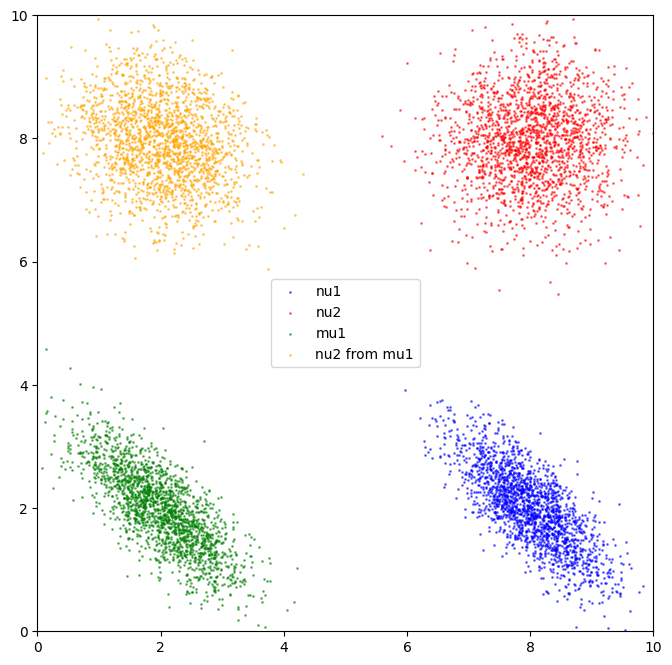

In [2]:
%autoreload 2
# test with samples from normal
n_samples_nu_1 = 2000
n_samples_nu_2 = 2000
n_samples_mu_1 = 2000

mean_nu1 = np.array([8, 2])
sigma_nu1 = np.array([[0.4, -0.3], [-0.3, 0.4]])

mean_nu2 = np.array([8, 8])
sigma_nu2 = np.array([[0.5, 0.0], [0.0, 0.5]])

mean_mu1 = np.array([2, 2])
sigma_mu1 = np.array([[0.4, -0.3], [-0.3, 0.4]])

# sample n_samples from nu_1, mu_1 and nu_2
nu1_samples = np.random.multivariate_normal(mean_nu1, sigma_nu1, size=n_samples_nu_1)
nu2_samples = np.random.multivariate_normal(mean_nu2, sigma_nu2, size=n_samples_nu_2)
mu1_samples = np.random.multivariate_normal(mean_mu1, sigma_mu1, size=n_samples_mu_1)

# obtain logmap from nu1 to nu2 and from nu1 to mu1
nu1_measure = EmpiricalMeasure(nu1_samples, np.ones(n_samples_nu_1) / n_samples_nu_1)
nu2_measure = EmpiricalMeasure(nu2_samples, np.ones(n_samples_nu_2) / n_samples_nu_2)
mu1_measure = EmpiricalMeasure(mu1_samples, np.ones(n_samples_mu_1) / n_samples_mu_1)

tangent_nu1_nu2 = wasserstein_logmap(nu1_measure, nu2_measure)
tangent_nu1_mu1 = wasserstein_logmap(nu1_measure, mu1_measure)

# parallel transport tangent_nu1_nu2 from nu1 to mu1
tangent_nu2_mu1 = tangent_nu1_nu2.parallel_transport(nu1_measure, mu1_measure, n=10, project=True)
# compute the exponential map of the transported tangent at mu1
nu2_from_mu1 = tangent_nu2_mu1.wasserstein_expmap()

# visualize by plotting and color-coding the measures (no tangents)
plt.figure(figsize=(8, 8))
plt.scatter(nu1_measure.locs[:, 0], nu1_measure.locs[:, 1], color='blue', alpha=0.5, label='nu1', s=1)
plt.scatter(nu2_measure.locs[:, 0], nu2_measure.locs[:, 1], color='red', alpha=0.5, label='nu2', s=1)
plt.scatter(mu1_measure.locs[:, 0], mu1_measure.locs[:, 1], color='green', alpha=0.5, label='mu1', s=1)
plt.scatter(nu2_from_mu1.locs[:, 0], nu2_from_mu1.locs[:, 1], color='orange', alpha=0.5, label='nu2 from mu1', s=1)
# set axis limits for better visualization
plt.xlim(0, 10)
plt.ylim(0, 10)
# set aspect ratio to equal for proper distance visualization
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()



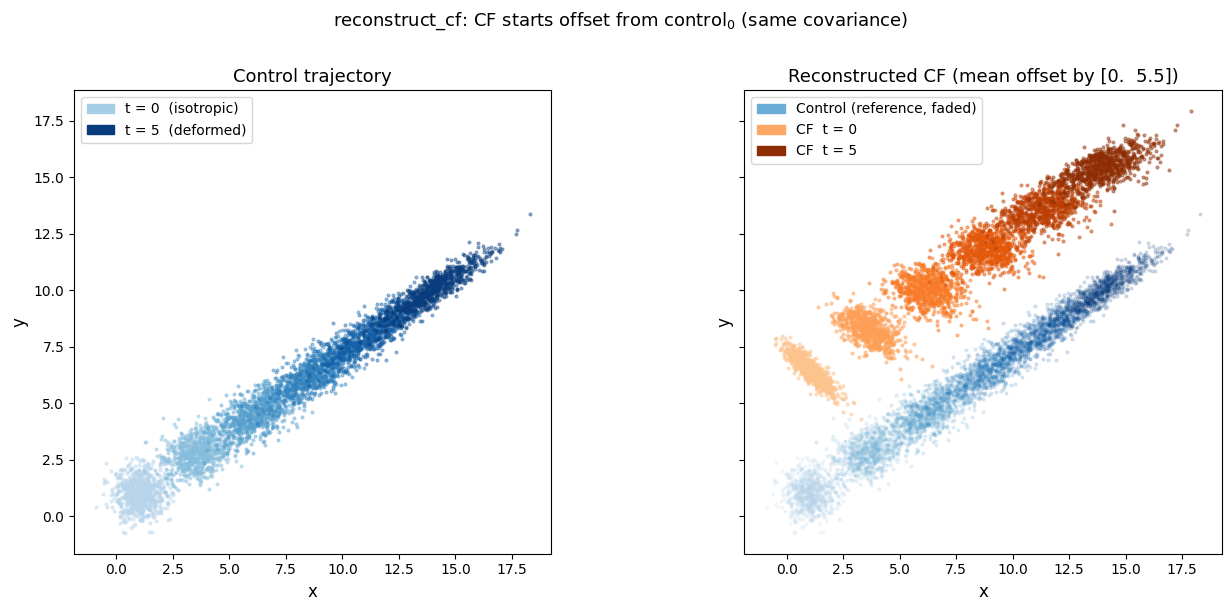

Control displacement : [12.99   9.001]
CF displacement      : [12.99   9.001]
Difference           : [0. 0.]

step             ctrl mean               CF mean
--------------------------------------------------
   0         [1.024 1.023]         [1.028 6.467]
   1         [3.613 2.838]         [3.616 8.282]
   2         [6.22  4.585]       [ 6.224 10.029]
   3         [8.81  6.384]       [ 8.814 11.828]
   4       [11.399  8.187]       [11.402 13.631]
   5       [14.015 10.024]       [14.018 15.468]


In [21]:
from src.cf_recon import reconstruct_cf
import matplotlib.cm as cm
from matplotlib.patches import Patch

np.random.seed(42)

# ── Control trajectory ────────────────────────────────────────────────────────
n_steps  = 5
n_samples = 800

mean_0 = np.array([1.0, 1.0])
mean_T = np.array([14.0, 10.0])

Sigma_0 = 0.35 * np.eye(2)                          # isotropic
Sigma_T = np.array([[1.4, 0.9], [0.9, 0.7]])        # elongated, tilted

control_samples = []
for i in range(n_steps + 1):
    alpha   = i / n_steps
    mean_i  = (1 - alpha) * mean_0 + alpha * mean_T
    Sigma_i = (1 - alpha) * Sigma_0 + alpha * Sigma_T
    control_samples.append(
        np.random.multivariate_normal(mean_i, Sigma_i, size=n_samples)
    )

# ── CF initial: same covariance as control[0], but offset mean ────────────────
cf_mean_0 = mean_0 + np.array([0.0, 5.5])           # shift upward
cf_sigma_0 = np.array([[0.35, -0.3], [-0.3, 0.35]]) 
# cf_sigma_0 = np.array([[0.1, -0.00], [-0.00, 0.1]])                         # smaller isotropic covariance
cf_0 = np.random.multivariate_normal(cf_mean_0, cf_sigma_0, size=n_samples)

# ── Reconstruct ───────────────────────────────────────────────────────────────
cf_curve = reconstruct_cf(control_samples, cf_0, n=n_steps, project=False)

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

blues   = cm.Blues
oranges = cm.Oranges

for ax in axes:
    ax.set_aspect('equal')
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)

# left panel: control trajectory
for i, s in enumerate(control_samples):
    c = blues(0.3 + 0.65 * i / n_steps)
    axes[0].scatter(s[:, 0], s[:, 1], color=c, s=4, alpha=0.4, rasterized=True)
axes[0].set_title('Control trajectory', fontsize=13)
axes[0].legend(handles=[
    Patch(color=blues(0.35), label='t = 0  (isotropic)'),
    Patch(color=blues(0.95), label=f't = {n_steps}  (deformed)'),
], loc='upper left', fontsize=10)

# right panel: control (faded) + CF (orange)
for i, s in enumerate(control_samples):
    c = blues(0.3 + 0.65 * i / n_steps)
    axes[1].scatter(s[:, 0], s[:, 1], color=c, s=4, alpha=0.15, rasterized=True)
for i, m in enumerate(cf_curve):
    c = oranges(0.3 + 0.65 * i / n_steps)
    axes[1].scatter(m.locs[:, 0], m.locs[:, 1], color=c, s=4, alpha=0.45, rasterized=True)
axes[1].set_title(f'Reconstructed CF (mean offset by {cf_mean_0 - mean_0})', fontsize=13)
axes[1].legend(handles=[
    Patch(color=blues(0.5),   label='Control (reference, faded)'),
    Patch(color=oranges(0.4), label='CF  t = 0'),
    Patch(color=oranges(0.95),label=f'CF  t = {n_steps}'),
], loc='upper left', fontsize=10)

plt.suptitle('reconstruct_cf: CF starts offset from control$_0$ (same covariance)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Quantitative check: mean displacement should be approximately preserved ───
ctrl_displacement = control_samples[-1].mean(axis=0) - control_samples[0].mean(axis=0)
cf_displacement   = cf_curve[-1].locs.mean(axis=0)   - cf_curve[0].locs.mean(axis=0)
print(f"Control displacement : {ctrl_displacement.round(3)}")
print(f"CF displacement      : {cf_displacement.round(3)}")
print(f"Difference           : {(ctrl_displacement - cf_displacement).round(3)}")

print(f"\n{'step':>4}  {'ctrl mean':>20}  {'CF mean':>20}")
print('-' * 50)
for i, (s, m) in enumerate(zip(control_samples, cf_curve)):
    print(f"{i:>4}  {str(s.mean(axis=0).round(3)):>20}  {str(m.locs.mean(axis=0).round(3)):>20}")